In [138]:
# imports
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob


In [139]:
# read in data
data = xr.open_dataset("D:\\Hiwi\\EFI_SOT_Kenya\\sample_T2m.nc")
#data_mclim = xr.open_mfdataset("D:/Hiwi/EFI_SOT_Kenya/m-climate/*.nc",combine="nested",concat_dim="init_time")

filelist = glob.glob("D:/Hiwi/EFI_SOT_Kenya/m-climate/*.nc")
filelist.sort()
data2 = None
for filepath in filelist:
    data_mclim = xr.open_dataset(filepath)
    data_mclim = data_mclim.isel(time=0)
    if data2 is None: data2 = data_mclim
    else: data2 = xr.concat((data2, data_mclim),dim="time")

data_mclim = data2


In [140]:
data_mclim = data2
data_mclim

<xarray.Dataset> Size: 494MB
Dimensions:   (time: 182, quantile: 101, lat: 40, lon: 42)
Coordinates:
  * time      (time) datetime64[ns] 1kB 2024-11-13 2024-11-15 ... 2025-11-11
  * quantile  (quantile) int32 404B 113793886 114907999 ... -207388818 190878303
  * lat       (lat) float64 320B -36.0 -34.5 -33.0 -31.5 ... 18.0 19.5 21.0 22.5
  * lon       (lon) float64 336B -3.0 -1.5 0.0 1.5 3.0 ... 54.0 55.5 57.0 58.5
Data variables:
    avg_2t    (time, quantile, lat, lon) float64 247MB 284.5 284.4 ... 300.1
    tp        (time, quantile, lat, lon) float64 247MB 1.137e-13 ... 48.8
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Jan 07 16:55:10 2026: cdo remapcon,targetgrid.txt yipin...
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

In [141]:
data

<xarray.Dataset> Size: 9MB
Dimensions:            (number: 50, time: 8, step: 46, latitude: 11,
                        longitude: 11)
Coordinates:
  * number             (number) int64 400B 1 2 3 4 5 6 7 ... 45 46 47 48 49 50
  * time               (time) datetime64[ns] 64B 2021-01-04 ... 2021-01-28
  * step               (step) timedelta64[ns] 368B 1 days 2 days ... 46 days
    valid_time         (time, step) datetime64[ns] 3kB ...
  * latitude           (latitude) float64 88B 7.5 6.0 4.5 3.0 ... -4.5 -6.0 -7.5
  * longitude          (longitude) float64 88B 30.0 31.5 33.0 ... 42.0 43.5 45.0
    heightAboveGround  float64 8B ...
Data variables:
    t2m                (number, time, step, latitude, longitude) float32 9MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-13T11:03 GRIB to CDM+CF via cfgrib-0.9.1...

In [142]:
### bring climatology and forecast to the same dimensions

# rename dims
data_changed = data.rename({"latitude":"lat","longitude":"lon"})
data_mclim_changed = data_mclim.rename({"avg_2t":"t2m"})

# time
data_changed = data_changed.sel(time=data_changed["time"].dt.month.isin(data_mclim_changed["time"].dt.month))
data_mclim_changed = data_mclim_changed.sel(time=data_mclim_changed["time"].dt.month.isin(data_changed["time"].dt.month))

data_f = data_changed.sel(time=data_changed["time"].dt.day.isin(data_mclim_changed["time"].dt.day))
data_clim = data_mclim_changed.sel(time=data_mclim_changed["time"].dt.day.isin(data_changed["time"].dt.day))

# lon and lat
data_f = data_f.sel(lon=data_f["lon"].isin(data_clim["lon"])).sel(lat=data_f["lat"].isin(data_clim["lat"]))
data_clim = data_clim.sel(lon=data_clim["lon"].isin(data_f["lon"])).sel(lat=data_clim["lat"].isin(data_f["lat"]))

data_clim
data_f

<xarray.Dataset> Size: 4MB
Dimensions:            (number: 50, time: 4, step: 46, lat: 11, lon: 11)
Coordinates:
  * number             (number) int64 400B 1 2 3 4 5 6 7 ... 45 46 47 48 49 50
  * time               (time) datetime64[ns] 32B 2021-01-07 ... 2021-01-25
  * step               (step) timedelta64[ns] 368B 1 days 2 days ... 46 days
    valid_time         (time, step) datetime64[ns] 1kB ...
  * lat                (lat) float64 88B 7.5 6.0 4.5 3.0 ... -3.0 -4.5 -6.0 -7.5
  * lon                (lon) float64 88B 30.0 31.5 33.0 34.5 ... 42.0 43.5 45.0
    heightAboveGround  float64 8B ...
Data variables:
    t2m                (number, time, step, lat, lon) float32 4MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-13T11:03 GRIB to CDM+CF via cfgrib-0.9.1...

In [143]:
### establish functions for EFI and SOT

# EFI
def EFI(data,data_mclim,ens_dim):
    '''
    Calculates the extreme forecast index (EFI) for a forecast with respect to the m-climate.
    
    Parameters:
        data (xr.ds): The forecast
        data_mclim (xr.ds): The m-climate
        ens_dim (str): The name of the dimension in data and data_mclim that contains the ensemble number

    Returns:
        EFI (xr.ds): The EFI for the given data and climatology
    '''
    p = np.linspace(0.01,0.99,99)

    # compute the p-th quantile of the ensemble dimension for the m-climate
    data_mclim_quantiled = data_mclim.where(~data_mclim["quantile"].isin([0,1]),drop=True)#data_mclim.quantile(p,ens_dim)
    quantile = data_mclim_quantiled["quantile"]

    # calculate Qf and compute the discretized integral w.r.t. p resp. quantile
    Qf = (data<data_mclim_quantiled).mean(ens_dim)
    result = 2/np.pi * ((quantile - Qf) / (quantile * (1-quantile))**.5).integrate("quantile")

    return result

# SOT
def SOT(data,data_mclim,ens_dim,upper_lower=False):
    '''
    Calculates the shift of tails from data with respect to the climatology in m-clim, for the difference between .9 and .99 percentiles

    Parameters:
        data (xr.ds): The forecast
        data_mclim (xr.ds): The m-climate
        ens_dim (str): The name of the dimension in data and data_mclim that contains the ensemble number
        upper_lower (bool): True if lower SOT (for .01 vs. .1 quantiles) shall be calculated in addition to the upper SOT
        
    Returns:
        SOT (xr.ds): The SOT for the given data and climatology
    '''
    if not upper_lower:
        p = [.9,.99]

        # compute the p-th quantile of the ensemble dimension
        data_mclim_quantiled = data_mclim.where(data_mclim["quantile"].isin(p),drop=True)#data_mclim.quantile(p,ens_dim)
        data_quantiled = data.quantile(p,ens_dim)

        # for readability
        Qf_90 = data_quantiled.sel(quantile=.9)
        Qc_90 = data_mclim_quantiled.sel(quantile=.9)
        Qc_99 = data_mclim_quantiled.sel(quantile=.99)

        # compute SOT
        result = (Qf_90 - Qc_99) / (Qc_99 - Qc_90)

        return result

    else:
        raise NotImplementedError("The lower SOT is not implemented as of now.")
    


In [144]:
### some further preparations

# aggregate the data to weekly forecast
data_f_calc = data_f.coarsen(step=7, boundary="trim").mean()

# set the step which we want to compare
data_f_calc = data_f_calc.isel(step=0)

# change the entries in the mclimate quantile column to the actual quantiles (due to a data issue)
data_clim_calc = data_clim.assign_coords(quantile=list(np.linspace(0,1,101)))

# align the times to the same year
data_clim_calc = data_clim_calc.assign_coords(time=data_f_calc["time"])



data_f_calc
#data_clim_calc

<xarray.Dataset> Size: 97kB
Dimensions:            (number: 50, time: 4, lat: 11, lon: 11)
Coordinates:
  * number             (number) int64 400B 1 2 3 4 5 6 7 ... 45 46 47 48 49 50
  * time               (time) datetime64[ns] 32B 2021-01-07 ... 2021-01-25
    valid_time         (time) datetime64[ns] 32B 2021-01-11 ... 2021-01-29
  * lat                (lat) float64 88B 7.5 6.0 4.5 3.0 ... -3.0 -4.5 -6.0 -7.5
  * lon                (lon) float64 88B 30.0 31.5 33.0 34.5 ... 42.0 43.5 45.0
    step               timedelta64[ns] 8B 4 days
    heightAboveGround  float64 8B ...
Data variables:
    t2m                (number, time, lat, lon) float32 97kB 304.0 ... 300.0
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-13T11:03 GRIB to CDM+CF via cfgrib-0.9.1...

In [145]:
### calculate

# EFI
efi = EFI(data_f_calc["t2m"],data_clim_calc["t2m"],"number")

# SOT
sot = SOT(data_f_calc["t2m"],data_clim_calc["t2m"],"number")


In [151]:
# ChatGPT plotting function
def plot_map(
    da,
    projection=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=None,
    vmax=None,
    title=None,
    figsize=(10,6),
):
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": projection}
    )

    # plot data
    im = da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        #cmap=cmap,
        #vmin=vmin,
        #vmax=vmax,
        #cbar_kwargs={"shrink": 0.7}
    )

    # map features
    ax.coastlines(resolution="110m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)

    # gridlines
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    if title:
        ax.set_title(title)

    plt.tight_layout()
    return fig, ax

<xarray.DataArray 't2m' (time: 4)> Size: 16B
array([303.96658, 304.19806, 303.71127, 305.24808], dtype=float32)
Coordinates:
  * time               (time) datetime64[ns] 32B 2021-01-07 ... 2021-01-25
    valid_time         (time) datetime64[ns] 32B 2021-01-11 ... 2021-01-29
    number             int64 8B 1
    step               timedelta64[ns] 8B 4 days
    heightAboveGround  float64 8B ...
    lat                float64 8B 7.5
    lon                float64 8B 30.0
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            pf
    GRIB_numberOfPoints:                      121
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avg
    ...                                       ...
    GRIB_shortName:                           2t
    GRIB_totalNumber:                         51
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            air_temperature

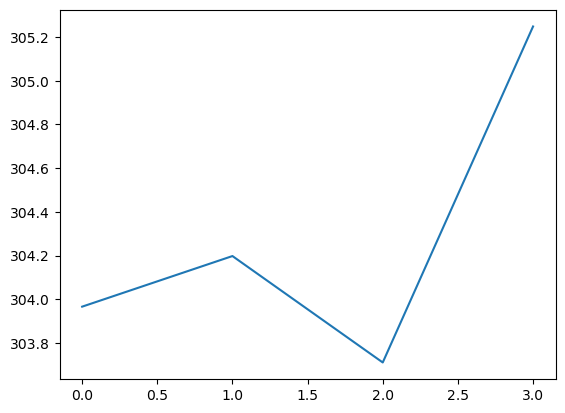

In [147]:
# plots
plt.plot(data_f_calc["t2m"].isel(lat=0,lon=0,number=0))
data_f_calc["t2m"].isel(lat=0,lon=0,number=0)

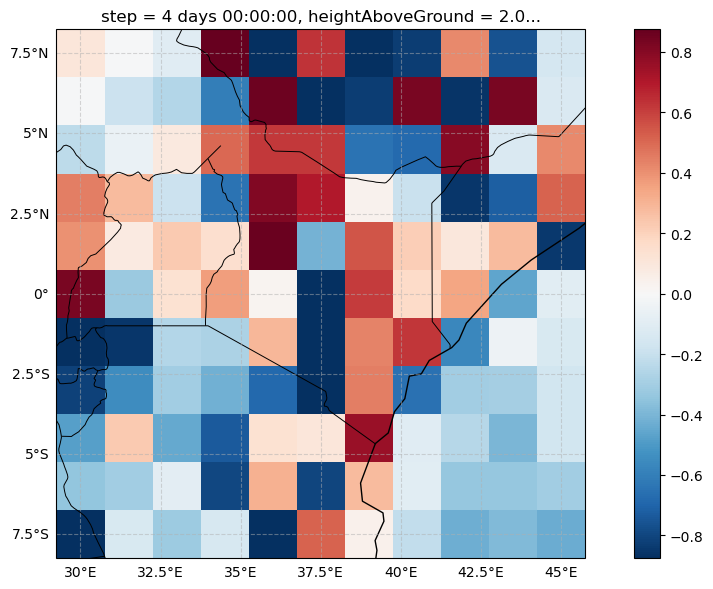

In [163]:

plot_map(efi.isel(time=2))
plt.show()
#efi

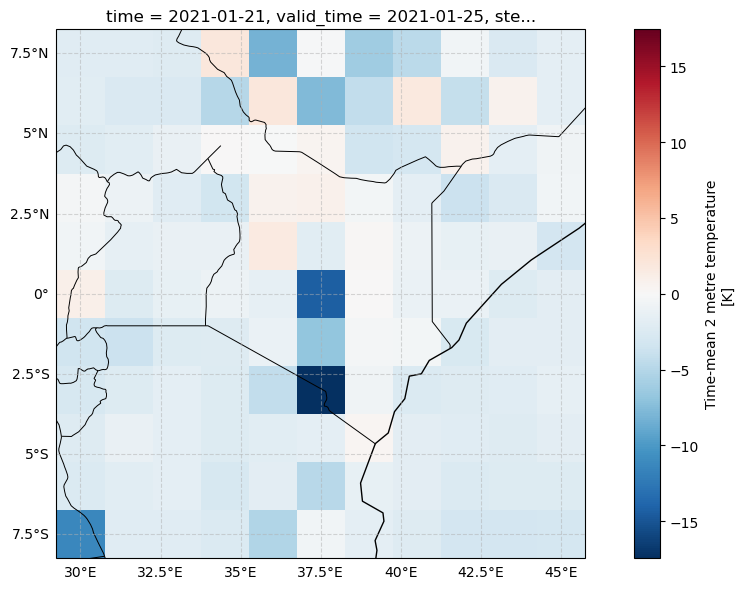

In [164]:
plot_map(sot.isel(time=2))
plt.show()